# 第4章 第一个程序 + 性能分析

## 本章导读

前两章已经解释了线程分工和数据位置。本章把它们收进一次完整实验：写 HIP 向量加法，
检查结果，再测量 PyTorch 向量加法，最后把时间换算成有明确含义的指标。

注意每个表格的实现名称。4.2 的 HIP 用来理解和验证手写程序，4.3 的主要计时对象是
`torch.add`；同样的数学运算不代表同一个底层实现。
[对应正文](../../../docs/part0-intro/chapter4/index.md)也按这一顺序展开。


## 4.1 准备环境

选择本篇已验证的 Python 内核，先读出当前环境与实验配置。`n` 默认是 `1 << 20`，
`block` 控制 HIP 每块线程数，`warmup` 和 `repeat` 控制测量，`seed` 固定随机输入。
它们集中在一个配置中，方便你只改一个条件后完整复跑。


In [ ]:
%run ../../common/bootstrap.py

import torch
import hello_gpu as gpu

cfg = gpu.settings()
torch.manual_seed(cfg["seed"])
%load_ext hello_gpu
cfg


In [ ]:
context = gpu.environment()
n, block = cfg["n"], cfg["block"]
torch.set_num_threads(1)
{"environment": gpu.environment(), "n": n, "block": block}


这里明确将 PyTorch CPU 算子线程数设为 1，记录时也会保存实际线程数。
这描述的是该算子的 CPU 配置，不等于整个系统只有一个活动线程。
环境尚未通过时，回到[第 1 章](../chapter1/chapter1.ipynb)检查最早失败的环节。


## 4.2 从向量加法到 HIP 程序

给定两个等长 FP32 数组，计算 `c[i] = a[i] + b[i]`。完整程序还包括输入准备、存储分配、
数据传递、提交计算和结果检查。在 notebook 中，Tensor 承担存储管理，HIP 单元保留线程的计算规则。


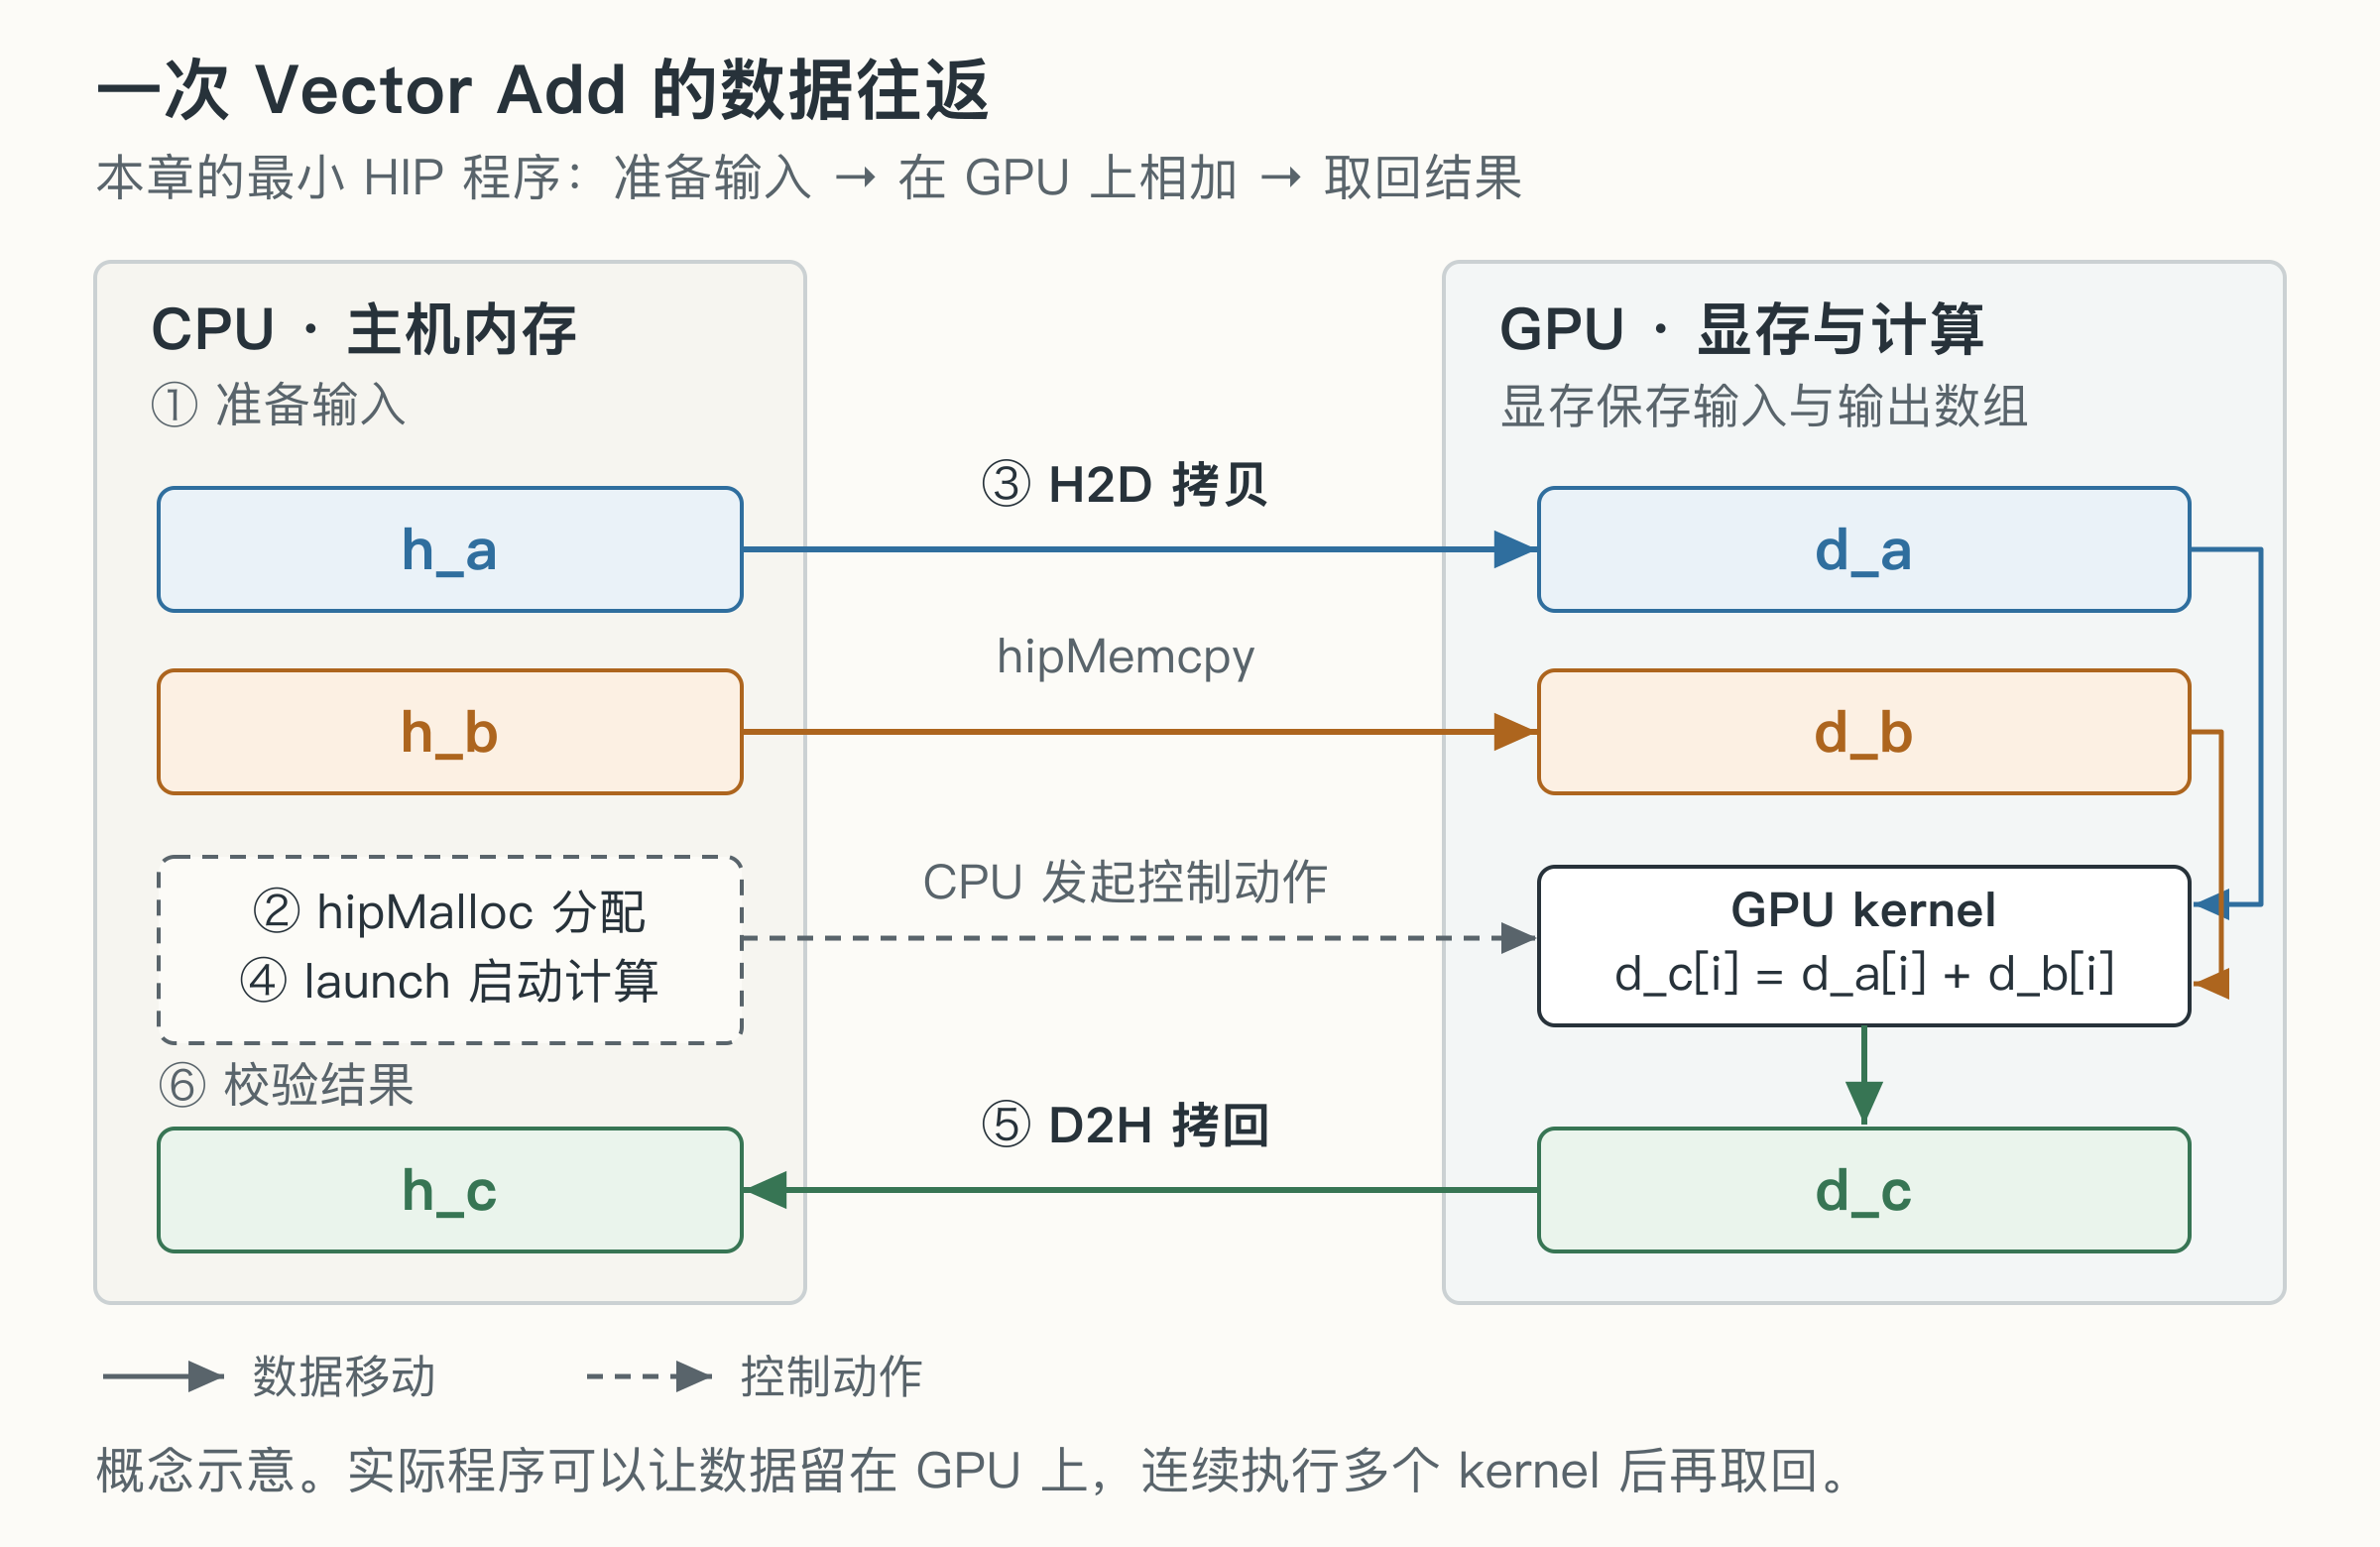

*先把数据路径说清楚，才能决定后面从哪里开始计时。*


In [ ]:
a_cpu = torch.randn(n, dtype=torch.float32)
b_cpu = torch.randn_like(a_cpu)
expected_cpu = a_cpu + b_cpu
a, b = a_cpu.to("cuda"), b_cpu.to("cuda")
hip_out = torch.empty_like(a)


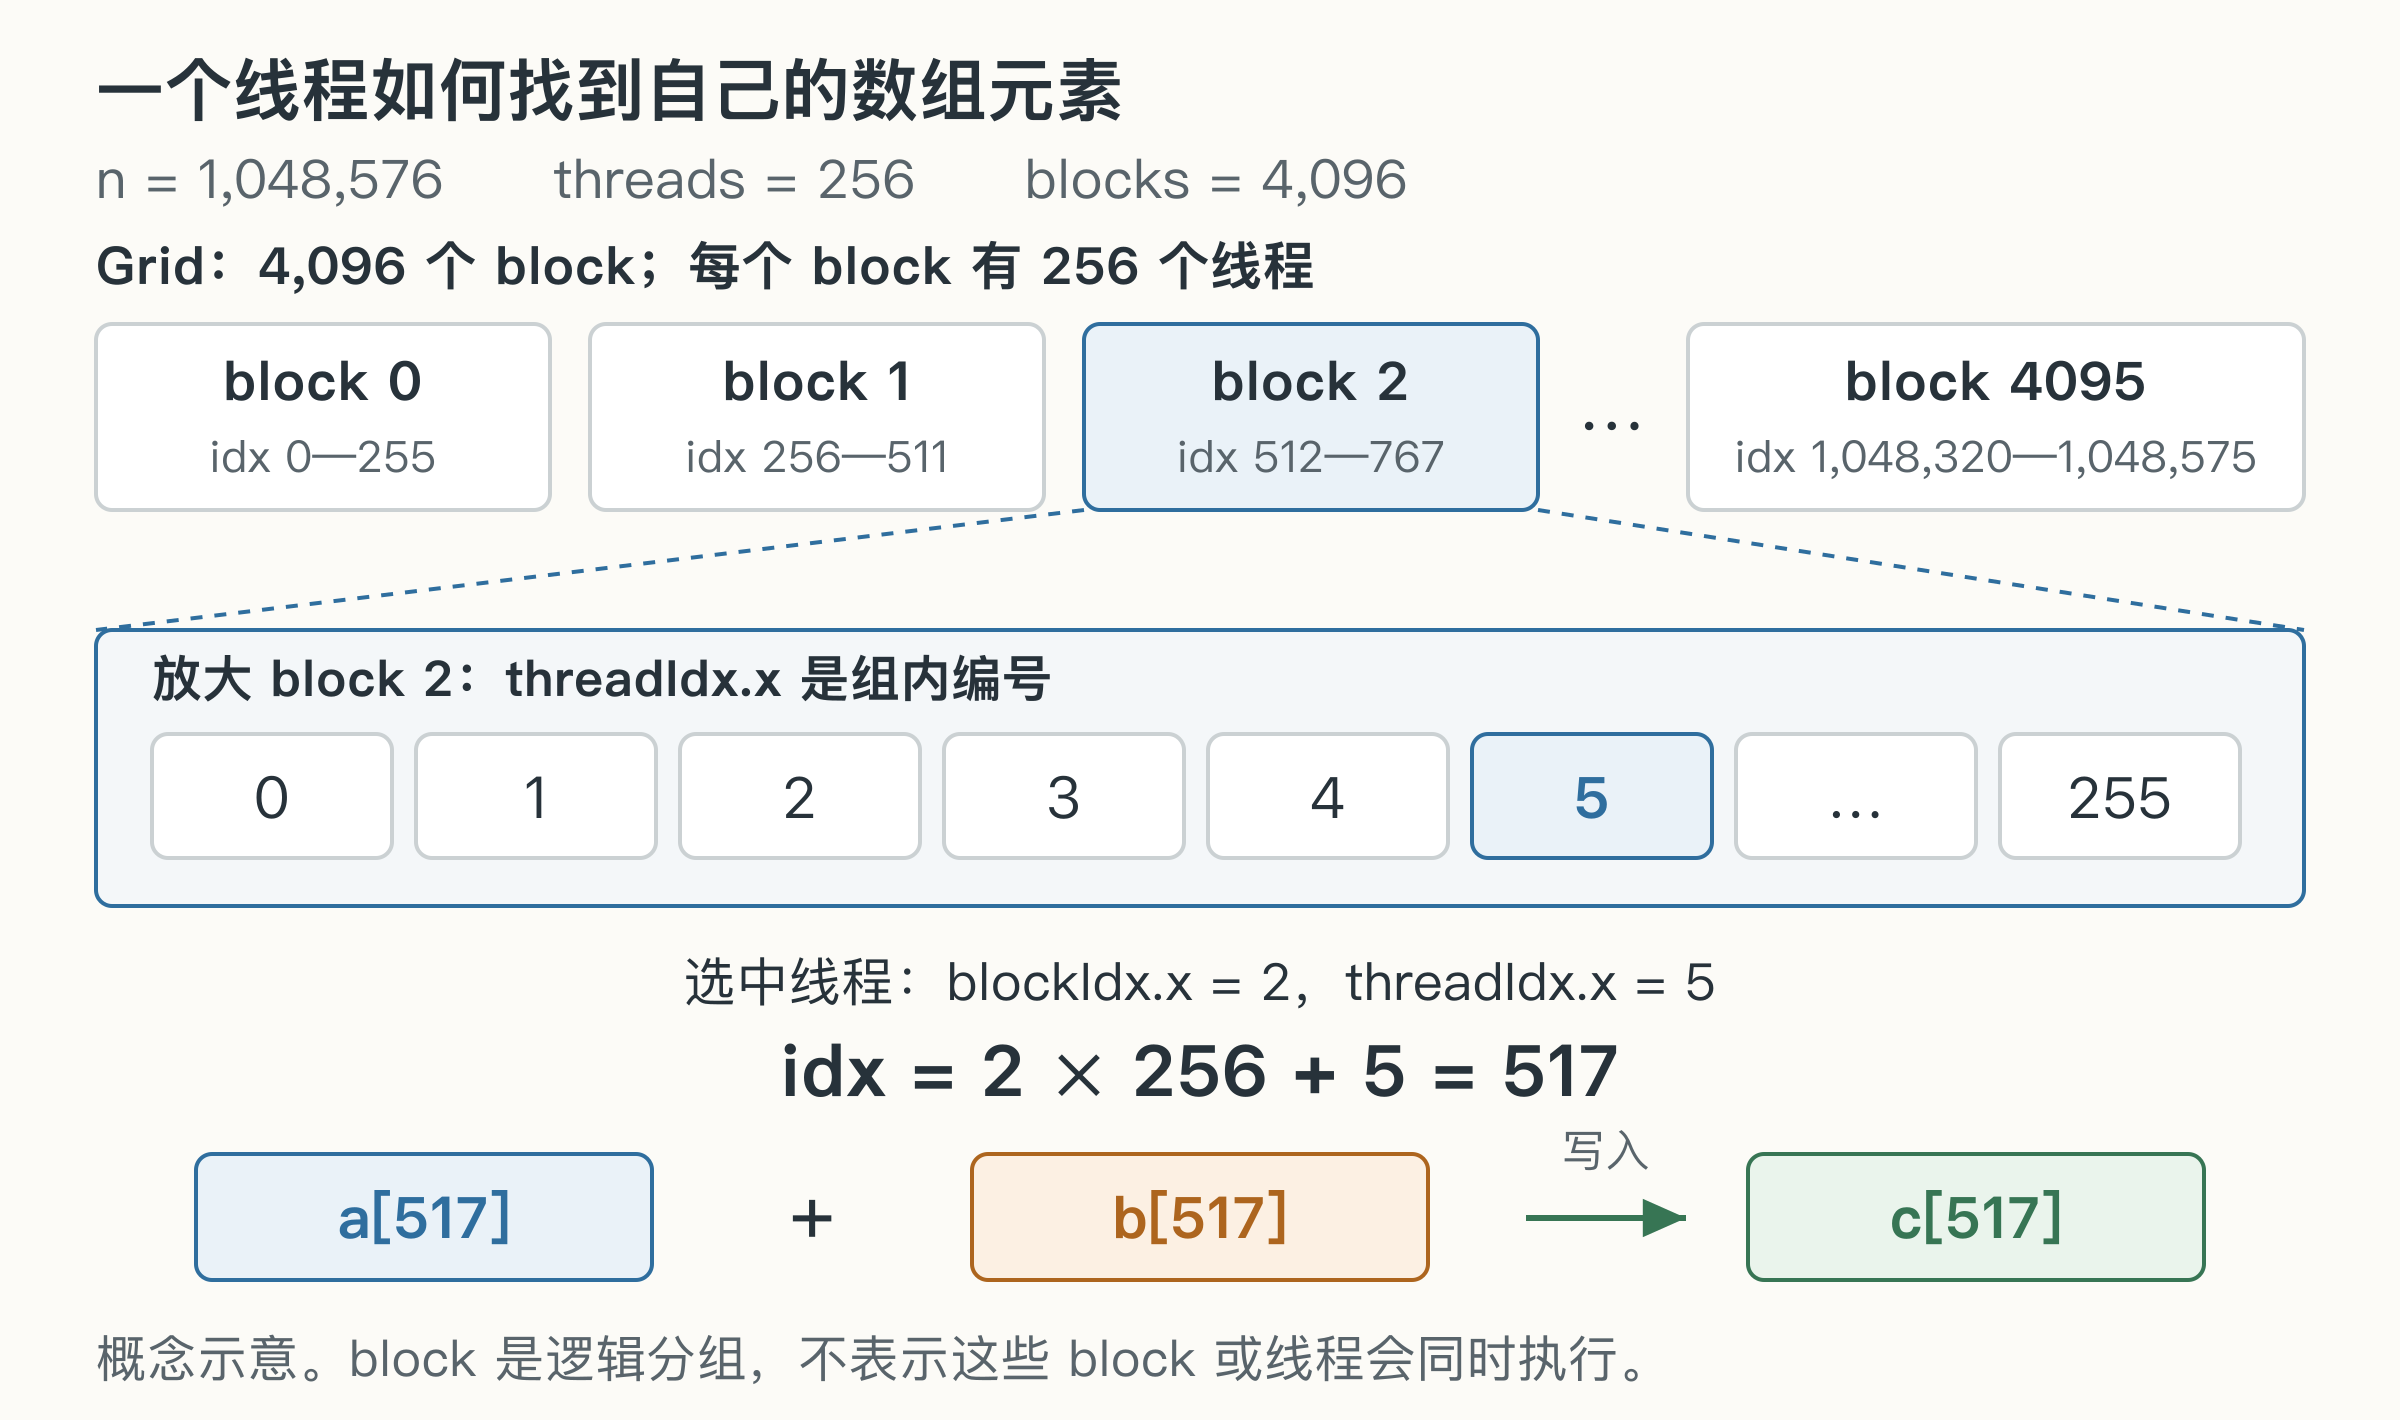

*块号乘块大小，加上块内线程号，得到本例采用的连续下标。*


In [ ]:
%%hip vector_add --preset binary_f32

__global__ void kernel(const float* a, const float* b, float* c, int n) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < n) c[i] = a[i] + b[i];
}


In [ ]:
vector_add(a, b, block=block, out=hip_out)
torch.testing.assert_close(hip_out.cpu(), expected_cpu, rtol=0, atol=0)
checked_lengths = [n]
for length in (0, 1, block - 1, block + 3, n + 3):
    x = torch.randn(length, device="cuda")
    y = torch.randn_like(x)
    torch.testing.assert_close(vector_add(x, y, block=block), x + y, rtol=0, atol=0)
    checked_lengths.append(length)
{"correct": True, "checked_lengths": checked_lengths}


**观察**：随机输入避免只检查“所有元素都是 3”这样的单一情况；非整除长度专门检查尾部。
我们在读取 CPU 结果后才宣布检查完成。到这里证明了这些输入上计算正确，还没有得到 HIP 的性能结论。


## 4.3 测量 PyTorch 向量加法

先固定要测量的工作：预先创建输入和输出，每次只执行 `torch.add(a, b, out=out)`。
CPU 使用主机时钟，GPU 使用当前执行流上的 event 区间。输入复制、输出分配和正确性检查都放在计时外。

GPU 提交是异步的。记录开始 event，提交加法，再记录结束 event；等待结束标记执行后，
才读取两个标记的时间差。预热用于越过首次运行状态，重复样本用于观察波动。


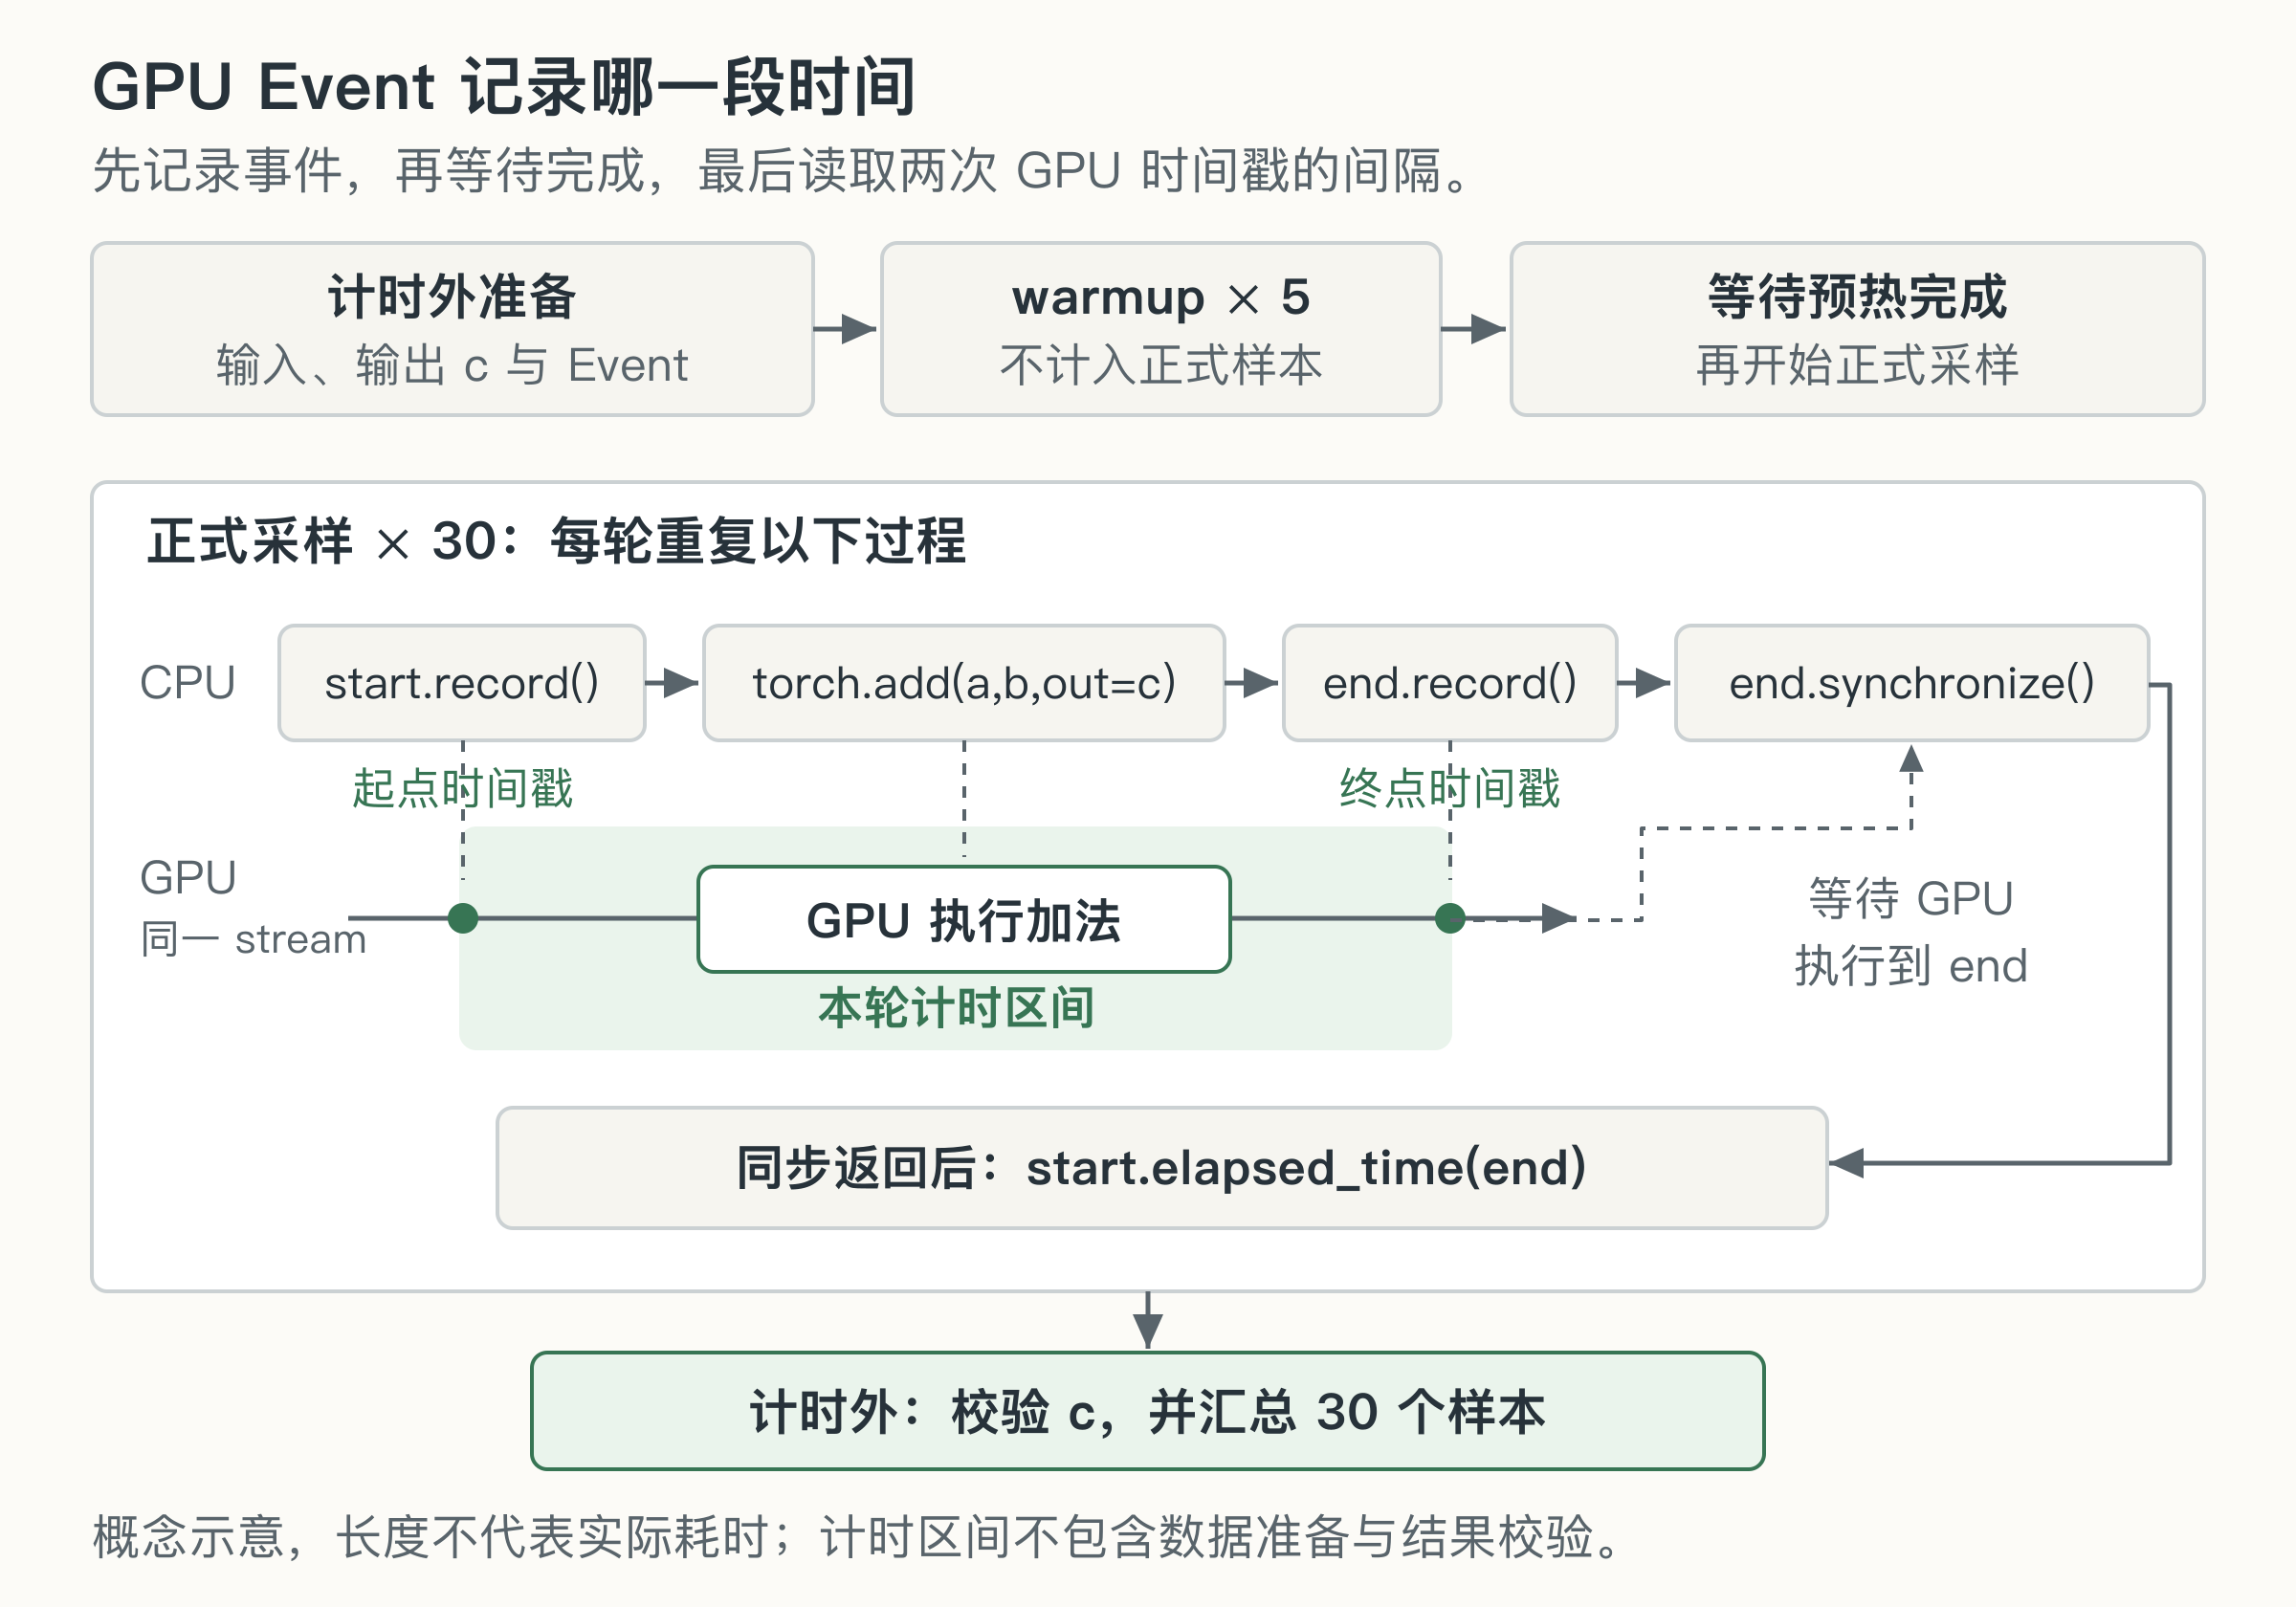

*event 确定测量区间，等待保证结束标记已完成；时间线不按真实耗时比例绘制。*


In [ ]:
cpu_out, torch_out = torch.empty_like(a_cpu), torch.empty_like(a)
cpu_call = lambda: torch.add(a_cpu, b_cpu, out=cpu_out)
gpu_call = lambda: torch.add(a, b, out=torch_out)
cpu_call()
gpu_call()
torch.testing.assert_close(cpu_out, expected_cpu, rtol=0, atol=0)
torch.testing.assert_close(torch_out.cpu(), expected_cpu, rtol=0, atol=0)


In [ ]:
cpu_measure = gpu.benchmark(cpu_call, device="cpu", label="PyTorch CPU add",
                            warmup=cfg["warmup"], repeat=cfg["repeat"])
gpu_measure = gpu.benchmark(gpu_call, label="PyTorch GPU add",
                            warmup=cfg["warmup"], repeat=cfg["repeat"])
measurements = [cpu_measure, gpu_measure]
table = gpu.summary(measurements)
table


**观察**：先读 `label`，确认这里测的是 PyTorch；再看 mean、median、min 是否接近。
中位数描述样本中间的位置，平均值受较大样本影响，最小值表示本次看到的最快样本。
它们都来自这次运行，不需要与正文历史数字相同。

CPU 的主机计时包含调用与计算；GPU event 区间可能受到提交节奏影响。
这两个边界各自有用，但不能把两者的差值简单解释成某一种硬件开销。
下面直接查看原始 GPU 样本，避免只盯着一个汇总值。


In [ ]:
import pandas as pd

pd.DataFrame({"sample": range(1, gpu_measure.repeat + 1),
              "PyTorch_GPU_ms": gpu_measure.samples_ms})


## 4.4 解释测量结果

FP32 加法对每个位置读取两个 4 字节输入，写出一个 4 字节输出，因此算法字节量模型是 `12 * n`。
用这个字节量除以时间得到有效带宽。它反映这份任务按该模型完成得有多快，
并非硬件计数器读到的物理显存流量，也不直接给出缓存命中率。

本节用中位数换算：时间以毫秒计时，十进制 GB/s 为 `bytes / median_ms / 1e6`。
零时间无法支撑带宽估算，应保留为缺失值。


In [ ]:
bytes_model = 3 * n * a.element_size()
table["effective_GB_s_by_median"] = bytes_model / table["median_ms"].replace(0, float("nan")) / 1e6
table.attrs["bytes_moved_model"] = bytes_model
table.attrs["bandwidth_statistic"] = "median"
table


In [ ]:
gpu.plot_times(table);


**观察**：公共绘图函数画的是最小延迟，表中的带宽采用中位数。图和表回答的是不同的统计问题，
比较时要看单位与标签，不能把图中的 min 当成表中的 median。
若样本波动很大，先检查其他负载、输入规模、预热与提交路径，再考虑改 kernel。

数组变大时，总时间与有效带宽都可能变化。只看一次测量无法保证趋势，
也不能据此宣布“已经达到硬件极限”。下一篇会继续补上 profiling 证据。


## 4.5 从算子时间到程序时间

刚才的输入已经在 GPU 上。真实调用者可能从 CPU 数组开始，一直等到 CPU 拿到结果。
为了比较范围，我们保留相同数学规则，测一个包含输入与输出传递的完整调用：
CPU 输入与 GPU 缓冲区都提前分配，计时内部复制输入、执行 PyTorch 加法、复制结果并等待完成。


In [ ]:
transfer_a, transfer_b = torch.empty_like(a), torch.empty_like(b)
transfer_out = torch.empty_like(a)
host_out = torch.empty_like(a_cpu)

def transfer_compute_return():
    transfer_a.copy_(a_cpu)
    transfer_b.copy_(b_cpu)
    torch.add(transfer_a, transfer_b, out=transfer_out)
    host_out.copy_(transfer_out)
    torch.cuda.current_stream().synchronize()

transfer_compute_return()
torch.testing.assert_close(host_out, expected_cpu, rtol=0, atol=0)
program_measure = gpu.benchmark(transfer_compute_return, device="cpu",
    label="PyTorch H2D + add + D2H + wait (preallocated)",
    warmup=cfg["warmup"], repeat=cfg["repeat"])
gpu.summary([gpu_measure, program_measure])


**观察**：第二行包含更多工作，且采用 CPU 主机时钟。它仍然没有包含 Python 启动、首次编译或
缓冲区分配，所以也不是整个进程的总耗时。性能数字只有和范围一起读才有含义。

再把输入缩小，观察提交与等待。下面调用的是我们写的 **HIP**，并比较三个范围：
批量提交的平均主机时间、一次提交加等待、GPU event 区间。
这些值包含 Python、C++ 包装、HIP 与队列路径，不能直接命名为“纯 HIP launch 耗时”。


In [ ]:
small_a = torch.randn(1, device="cuda")
small_b = torch.randn_like(small_a)
small_out = torch.empty_like(small_a)
small_call = vector_add.prepare(small_a, small_b, block=block, out=small_out)
small_call()
torch.testing.assert_close(small_out, small_a + small_b, rtol=0, atol=0)
overhead = gpu.launch_overhead(small_call, warmup=cfg["warmup"], repeat=cfg["repeat"])
overhead


一次很小的操作可能主要受调用路径影响；把多步工作留在 GPU 上，可以让一次输入传递服务于更多计算。
是否值得迁移到 GPU，要测你的实际流程，不存在本章能给出的统一元素数分界线。


## 4.6 记录与练习

把本次配置、正确性、源码、环境与原始时间样本放在一起，下一次才知道哪些条件发生了变化。
本记录明确标记：主要算子测量来自 PyTorch，短调用范围观察来自 HIP；没有把二者混成一组性能结果。


In [ ]:
record = gpu.save_record("part0-intro/chapter4", kernel=vector_add,
    config={**cfg, "shape": [n], "dtype": "float32", "correct": True,
            "checked_lengths": checked_lengths, "entry": "chapter4.ipynb",
            "goal": "验证 HIP 加法，学习 PyTorch 加法与程序范围计时",
            "timed_operator": "torch.add; HIP only in small-call overhead",
            "program_boundary": "preallocated H2D + torch.add + D2H + wait",
            "cpu_threads": torch.get_num_threads(), "bytes_model": bytes_model},
    measurements=[cpu_measure, gpu_measure, program_measure], overhead=overhead)
record


### 练习

1. 保持 block 不变，手算 `N=1000` 的 grid 和尾部，再运行 4.2 的正确性检查。
2. 在配置中改变 `n`，保持 seed、warmup、repeat 与 CPU 线程数一致，重启并运行全部。
   比较 mean、median、min 和有效带宽，记录观察到的变化，不预设某个规模必须更快。
3. 用本次中位数手算 `12N/t`。先把毫秒换成秒，再把字节换成十进制 GB，核对表中的值。
4. 若移除读取 event 时间前的等待，缺失了什么保证？提交结束标记是否等于设备已经执行完它？
5. 将完整调用改成“输入在 GPU 上连续做多次加法，最后才取回一次”。先定义每次的正确结果，
   再决定分配、传递、等待各自放在哪里。比较时完整写出测量范围。

## 本章小结

我们把一次实验拆成输入与输出约定、HIP 正确性、PyTorch 算子时间和主机可见的程序时间。
有效带宽来自明确的字节量模型，结论来自本次运行的样本。
下一章进入[第 5 章：benchmark 与可信计时](../../part1-profiling/chapter5/chapter5.ipynb)，
继续检查测量波动，以及怎样在相同条件下比较不同实现。
